In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [ ]:
df = pd.read_csv("/content/bodyPerformance.csv")

## Taking copy not to load the data again

In [ ]:
df2 = df.copy()

## To Display all the columns

In [ ]:
pd.set_option('display.max_columns', None)
display(df2.head())

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


## 2. Data Cleaning: Nulls & Duplicates

**Theory:**
Errors include "mismatches with ground truth," rule violations (e.g., negative age), or pattern violations.

### A. Duplicate Analysis
**Logic:**
* **Exact Duplicates:** Typically data entry errors (uploading the same file twice). **Action:** Remove.

### B. Missing Value (Null) Analysis
**Logic:**
* **Missing < 5%:** Often safe to **Drop** rows.
* **Missing > 5% but < 30%:** **Impute**.
    * *Numerical (Normal):* Impute with **Mean**.
    * *Numerical (Skewed/Outliers):* Impute with **Median** (robust to outliers).
    * *Categorical:* Impute with **Mode** (Most Frequent) or create a "Missing" category.
* **Missing > 30-50%:** Consider it and then choose to **Drop the Column** or **Fill it** as it contains critical information.

In [ ]:
# 1. Duplicates
dupes = df2.duplicated().sum()
if dupes > 0:
    print(f"Found {dupes} duplicate rows ({dupes/len(df2)*100}%).")
    print("   -> ACTION: Dropping exact duplicates (Data Entry Error Assumption).")
    df2 = df2.drop_duplicates()
else:
    print("No exact duplicates found.")

# 2. Null Values
nulls = df2.isnull().sum()
nulls = nulls[nulls > 0]

if len(nulls) > 0:
    print(f"\nFound Null Values in {len(nulls)} columns:")
    print(nulls)

    # Decision Logic for Nulls
    for col in nulls.index:
        pct_missing = (df2[col].isnull().sum() / len(df2)) * 100
        dtype = df2[col].dtype

        print(f"Example Strategy for '{col}' ({pct_missing}% missing):")
        if pct_missing < 5:
            print("     -> ACTION: Drop Rows (Low impact).")
            # df2 = df2.dropna(subset=[col])
        elif pct_missing > 50:
            print("     -> ACTION: Drop Column (Too much missing info) Unless meta data.")
            # df = df.drop(columns=[col])
            # df2[col] = df2[col].fillna("unknown")
        else:
            if np.issubdtype(dtype, np.number):
                skew = df2[col].skew()
                if abs(skew) > 1:
                    print("     -> ACTION: Impute with MEDIAN (Distribution is Skewed).")
                    # df[col] = df[col].fillna(df[col].median())
                else:
                    print("     -> ACTION: Impute with MEAN (Distribution is Normal).")
                    # df[col] = df[col].fillna(df[col].mean())
            else:
                print("     -> ACTION: Impute with MODE (Categorical).")
                # df[col] = df[col].fillna(df[col].mode()[0])
else:
    print("No missing values found.")



Found 1 duplicate rows (0.007466587023071754%).
   -> ACTION: Dropping exact duplicates (Data Entry Error Assumption).
No missing values found.


## 3. Univariate Analysis: Quantitative (Numerical)

**Theory:**
We examine the "Sample Distribution" to infer population properties.
Key metrics include:
* **Center:** Mean (balance point), Median (robust middle).
* **Spread:** Variance/SD (sensitive to outliers), IQR (robust).
* **Shape:** Skewness (asymmetry).

### Interpretation & Actions Checklist:
1.  **Skewness > 1 or < -1:** Data is highly skewed.
    * *Observation:* Mean != Median.
    * *Action:* Apply **Log Transformation**.
2.   **Outliers (Boxplot Rule):** Points beyond 1.5 * IQR.
* *Action (Error):* If value is impossible (e.g., Age 150), **Remove** or Fix.
* *Action (Valid):* If value is rare but real (e.g., Billionaire income).

Univariate Analysis: age 
Mean: 36.77583632019116 | Median: 32.0 | Std: 13.625886370313028
Skewness: 0.5997745750174289 (Target: 0) 


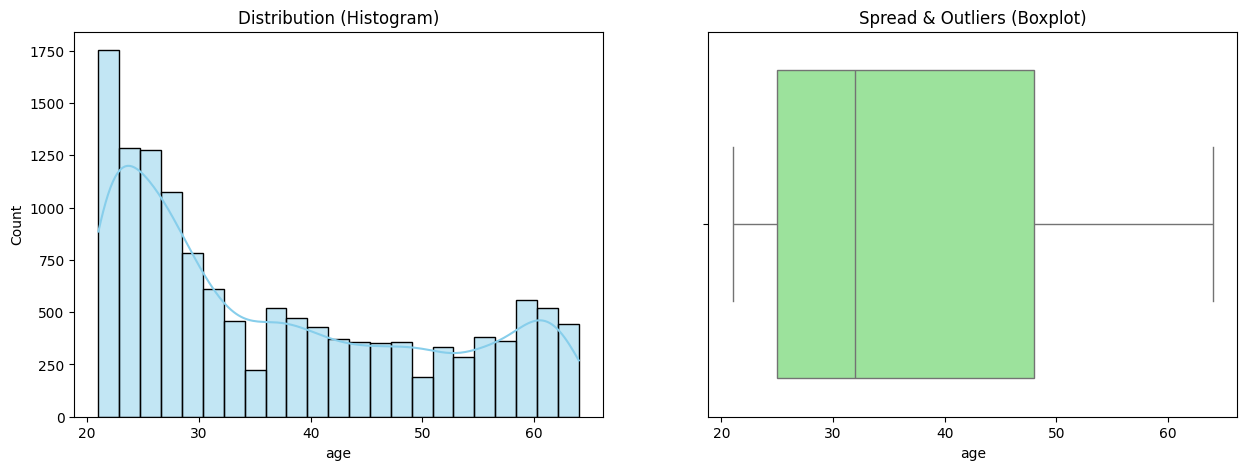

🔍 INSIGHTS & ACTIONS:
   ✅ No statistical outliers detected via IQR method.
Univariate Analysis: height_cm 
Mean: 168.56067054958183 | Median: 169.2 | Std: 8.426305021941026
Skewness: -0.18702929884607386 (Target: 0) 


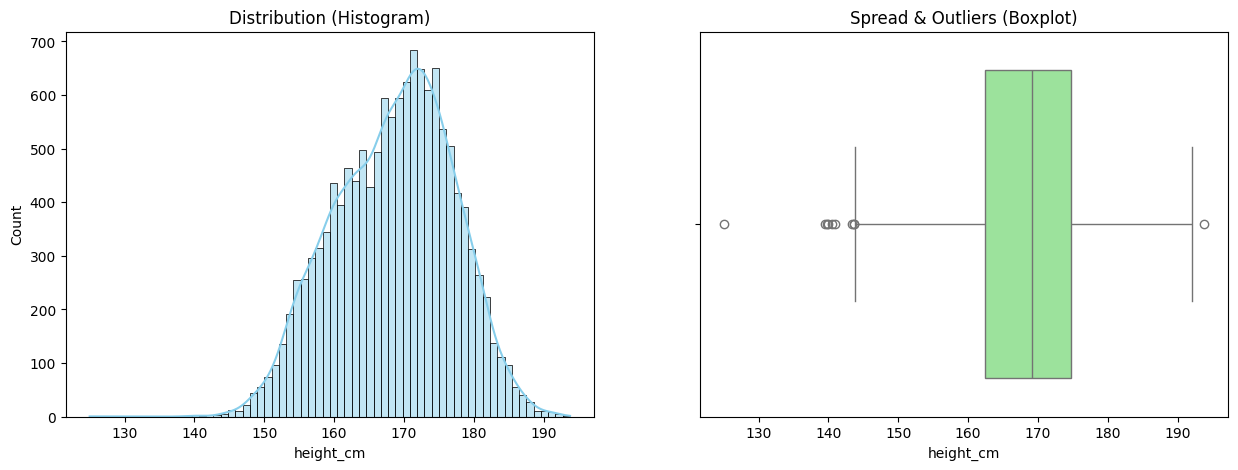

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 10 Outliers (Values < 143.80 or > 193.40).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.
Univariate Analysis: weight_kg 
Mean: 67.44868578255675 | Median: 67.4 | Std: 11.949060599786359
Skewness: 0.34981028253972635 (Target: 0) 


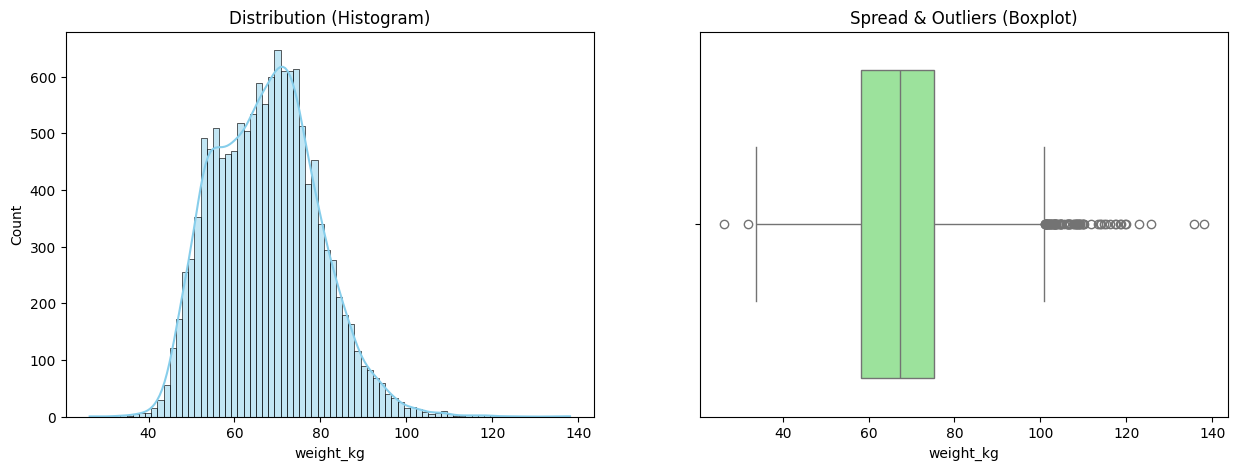

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 83 Outliers (Values < 32.55 or > 100.95).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.
Univariate Analysis: body fat_% 
Mean: 23.23960791420251 | Median: 22.8 | Std: 7.256828687758807
Skewness: 0.36131070181674746 (Target: 0) 


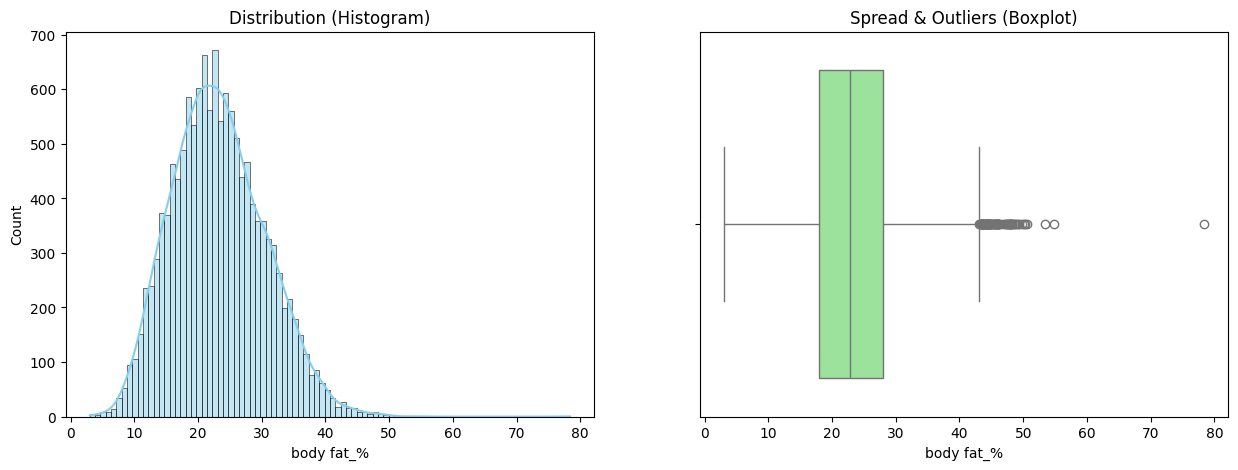

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 77 Outliers (Values < 3.00 or > 43.00).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.
Univariate Analysis: diastolic 
Mean: 78.79749850657107 | Median: 79.0 | Std: 10.742165188014265
Skewness: -0.15978566295599042 (Target: 0) 


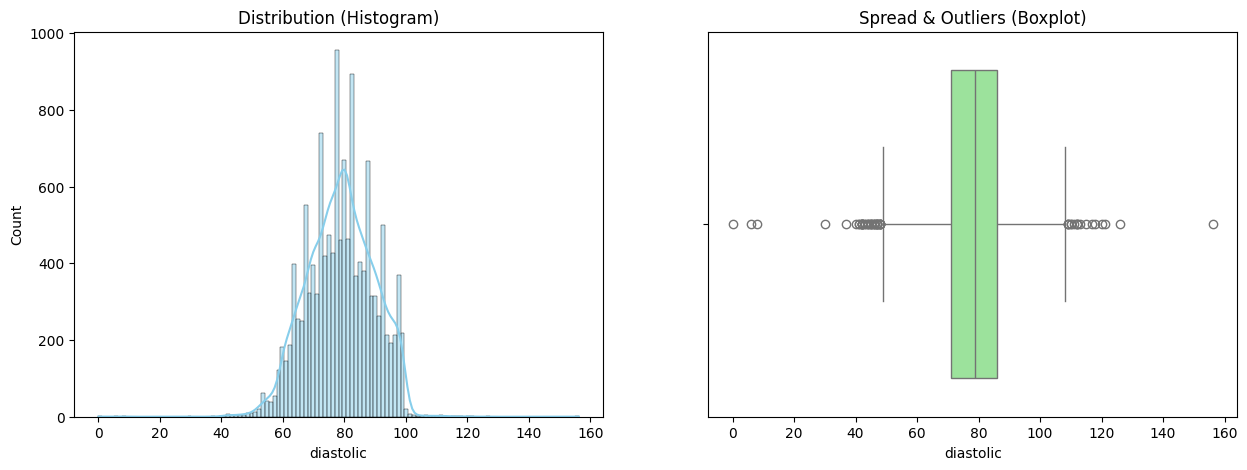

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 54 Outliers (Values < 48.50 or > 108.50).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.
Univariate Analysis: systolic 
Mean: 130.2381197729988 | Median: 130.0 | Std: 14.70953646403494
Skewness: -0.047343674711883145 (Target: 0) 


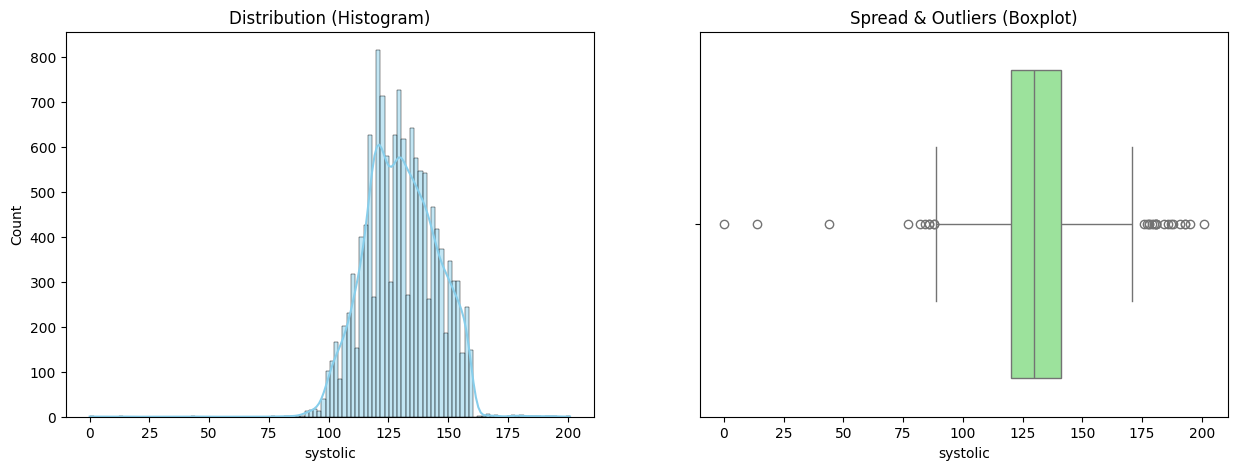

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 28 Outliers (Values < 88.50 or > 172.50).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.
Univariate Analysis: gripForce 
Mean: 36.96456914575866 | Median: 37.9 | Std: 10.624959129412122
Skewness: 0.018311534397075332 (Target: 0) 


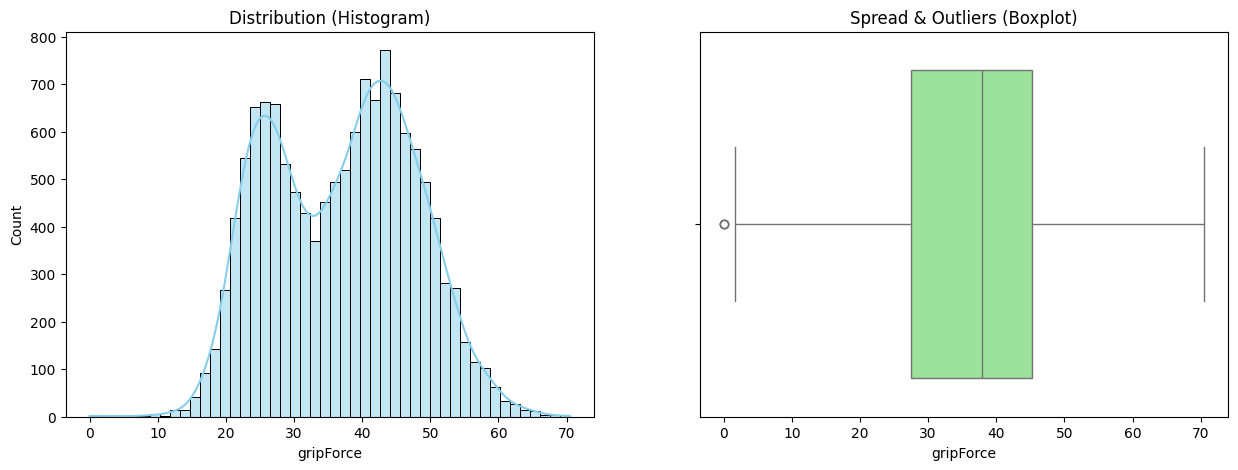

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 3 Outliers (Values < 0.95 or > 71.75).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.
Univariate Analysis: sit and bend forward_cm 
Mean: 15.208932945041818 | Median: 16.2 | Std: 8.456903717983351
Skewness: 0.7855952903090573 (Target: 0) 


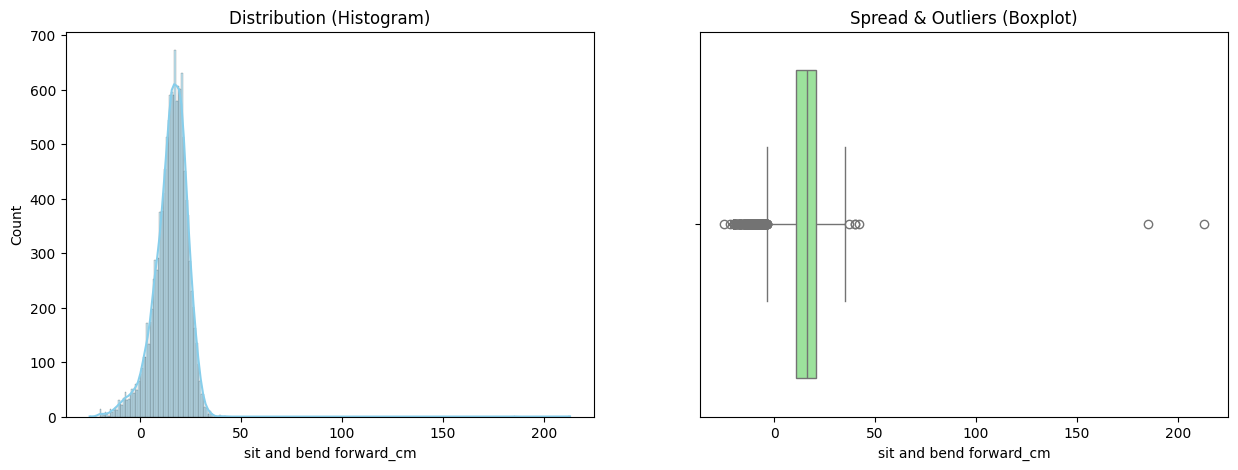

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 409 Outliers (Values < -3.80 or > 35.40).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.
Univariate Analysis: sit-ups counts 
Mean: 39.7703853046595 | Median: 41.0 | Std: 14.276901614431251
Skewness: -0.4677049566254682 (Target: 0) 


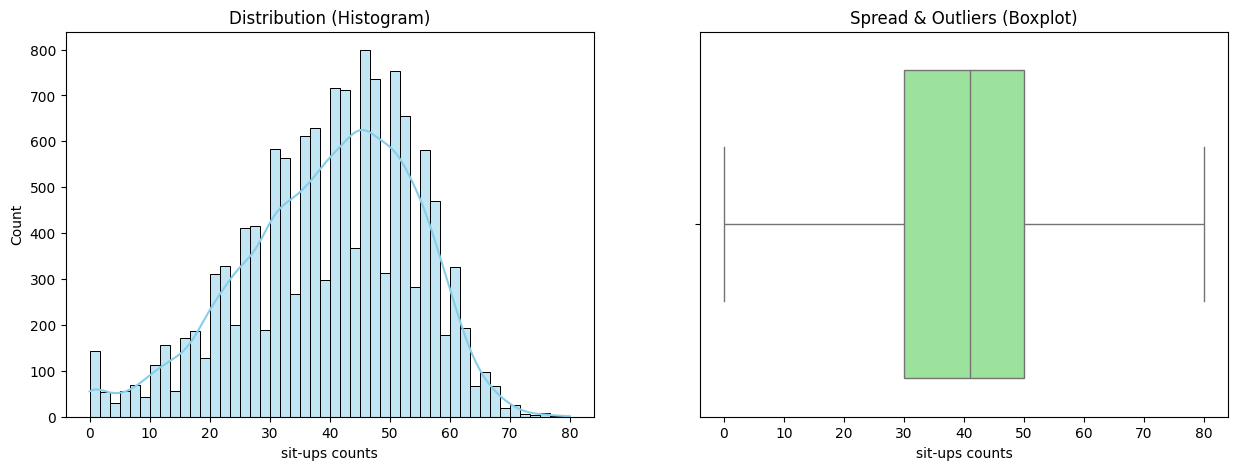

🔍 INSIGHTS & ACTIONS:
   ✅ No statistical outliers detected via IQR method.
Univariate Analysis: broad jump_cm 
Mean: 190.1313545400239 | Median: 193.0 | Std: 39.86898765773046
Skewness: -0.42273811129113775 (Target: 0) 


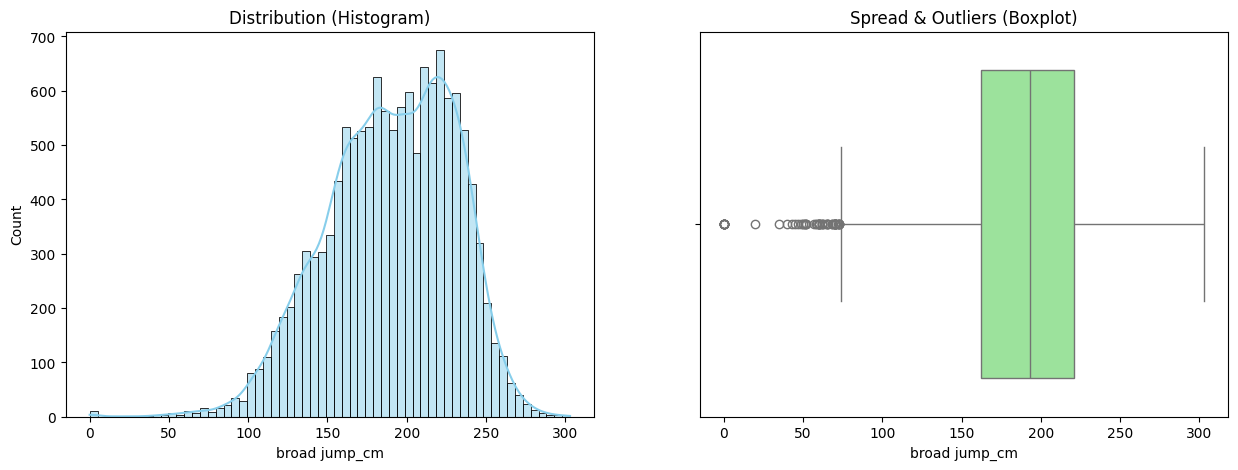

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 57 Outliers (Values < 73.50 or > 309.50).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.


In [ ]:
def analyze_numerical_variable(df, column):
    print(f"Univariate Analysis: {column} ")

    # 1. Non-Graphical Stats
    desc = df[column].describe()
    skew = df[column].skew()

    print(f"Mean: {desc['mean']} | Median: {desc['50%']:} | Std: {desc['std']:}")
    print(f"Skewness: {skew} (Target: 0) ")

    # 2. Visualizations (Histogram, Boxplot, Q-Q Plot)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Histogram with KDE (Density)
    sns.histplot(df[column].dropna(), kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribution (Histogram)')

    # Boxplot (Outlier Detection)
    sns.boxplot(x=df[column], ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Spread & Outliers (Boxplot)')


    plt.show()

    # 3. Automated Insights & Actions
    print("🔍 INSIGHTS & ACTIONS:")

    # Skewness check
    if abs(skew) > 1:
        print(f"   ⚠️ High Skewness ({skew:.2f}).")
        print("      -> ACTION: Consider Log Transformation (np.log1p) or Square Root transformation.")

    # Outlier check (IQR Method)
    Q1 = desc['25%']
    Q3 = desc['75%']
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]

    if len(outliers) > 0:
        print(f"   ⚠️ Found {len(outliers)} Outliers (Values < {lower:.2f} or > {upper:.2f}).")
        print("      -> ACTION (If Error): Remove rows (e.g., negative Age).")
        print("      -> ACTION (If Valid): Cap values at min/max thresholds.")
    else:
        print("   ✅ No statistical outliers detected via IQR method.")

# Execution for numerical columns
num_cols = df2.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    analyze_numerical_variable(df2, col)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Handle Blood Pressure (Removing Logical Errors)
# Values <= 40 are medically impossible for an active person; removing them ensures data quality.
df = df[(df['systolic'] > 40) & (df['diastolic'] > 40)]

# 2. Handle "sit and bend forward_cm" (Capping/Clipping Outliers)
# Extreme values like 213cm are likely input errors.
# Clipping preserves the data point while neutralizing the impact of the error.
upper_limit = 50
lower_limit = -20
df['sit and bend forward_cm'] = df['sit and bend forward_cm'].clip(lower=lower_limit, upper=upper_limit)

# 3. Feature Engineering: Calculate BMI
# BMI provides a standardized ratio of weight to height, helping the model identify body composition trends.
df['BMI'] = df['weight_kg'] / ((df['height_cm'] / 100) ** 2)

# 4. Categorical Encoding
# Convert Gender to binary (M=0, F=1)
df['gender'] = df['gender'].map({'M': 0, 'F': 1})

# Encode Target Class (A, B, C, D) into numerical values (0, 1, 2, 3)
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

# Summary of cleaning process
print(f"Cleaning complete! Remaining rows: {len(df)}")
print(df[['systolic', 'diastolic', 'sit and bend forward_cm']].describe())

Cleaning complete! Remaining rows: 13386
           systolic     diastolic  sit and bend forward_cm
count  13386.000000  13386.000000             13386.000000
mean     130.259219     78.824003                15.188535
std       14.630475     10.667022                 8.159867
min       43.900000     41.000000               -20.000000
25%      120.000000     71.000000                10.900000
50%      130.000000     79.000000                16.200000
75%      141.000000     86.000000                20.700000
max      201.000000    156.200000                50.000000


## 4. Univariate Analysis: Categorical

**Theory:**
For categorical data, concepts like Mean/Std Dev don't exist.  We focus on **Frequency** and **Relative Frequency (Proportion)**.

### Interpretation & Actions Checklist:
1.  **Dominant Class (Low Variance):**
    * *Observation:* 99% of data is "Category A".
    * *Action:* Drop the feature. It provides no information for the model to learn differences.
2.  **Inconsistent Labeling (Pattern Violation):**
    * *Observation:* "NY", "ny", "New York".
    * *Action:* Standardize strings (lowercase, strip whitespace).


--- 📊 Univariate Analysis: gender ---


,Count,Percentage
gender,,
M,8467,63.224313
F,4925,36.775687


/tmp/ipykernel_558/2671505446.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], order=counts.index, palette='viridis')


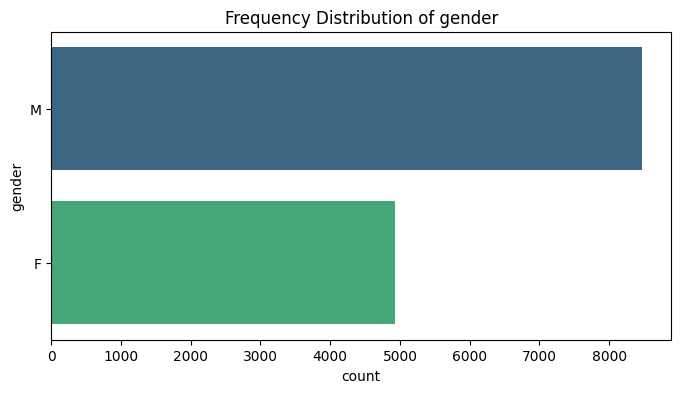

🔍 INSIGHTS & ACTIONS:
      -> NOTE: Check for mixed case labels (e.g., 'Male' vs 'male') and standardize.

--- 📊 Univariate Analysis: class ---


,Count,Percentage
class,,
C,3349,25.007467
D,3349,25.007467
A,3347,24.992533
B,3347,24.992533


/tmp/ipykernel_558/2671505446.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], order=counts.index, palette='viridis')


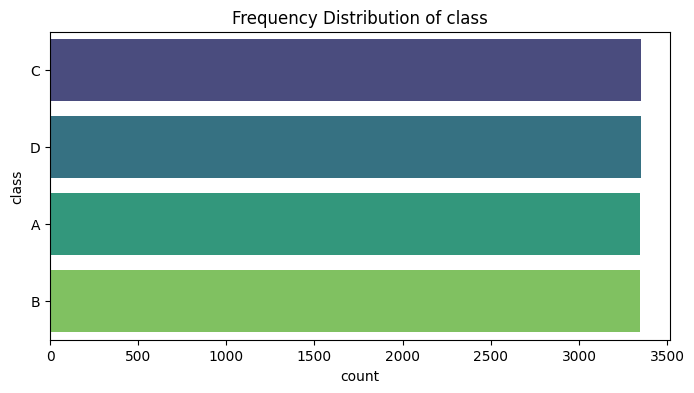

🔍 INSIGHTS & ACTIONS:
      -> NOTE: Check for mixed case labels (e.g., 'Male' vs 'male') and standardize.


In [ ]:
def analyze_categorical_variable(df, column):
    print(f"\n--- 📊 Univariate Analysis: {column} ---")

    # 1. Non-Graphical Stats
    counts = df[column].value_counts()
    props = df[column].value_counts(normalize=True) * 100

    # Combine into a dataframe for display
    summary = pd.DataFrame({'Count': counts, 'Percentage': props})
    display(summary)

    # 2. Visualization (Bar Plot)
    plt.figure(figsize=(8, 4))
    sns.countplot(y=df[column], order=counts.index, palette='viridis')
    plt.title(f'Frequency Distribution of {column}')
    plt.show()

    # 3. Automated Insights & Actions
    print("🔍 INSIGHTS & ACTIONS:")

    # Check for Dominant Class
    if props.iloc[0] > 95:
        print(f"   ⚠️ Dominated Feature: '{counts.index[0]}' is {props.iloc[0]:.2f}% of data.")
        print("      -> ACTION: Consider dropping this column (insufficient variance).")

    # Check for Dirty Data (Example logic)
    # Checking if multiple indices look similar (e.g., 'NY' and 'ny')
    if df[column].dtype == 'object':
        print("      -> NOTE: Check for mixed case labels (e.g., 'Male' vs 'male') and standardize.")

# Execution for categorical columns
cat_cols = df2.select_dtypes(include=['object', 'category']).columns.tolist()

for col in cat_cols:
    if df2[col].nunique() < 30:
        analyze_categorical_variable(df2, col)
    elif df2[col].nunique() < 100 :
        # For high-cardinality columns, group non-top-20 values into 'Others'
        top_20 = df2[col].value_counts().index[:20]
        df_temp = df2[[col]].copy()
        df_temp[col] = df_temp[col].where(df_temp[col].isin(top_20), 'Others')
        analyze_categorical_variable(df_temp, col)
    else:
        continue

## 5. Multivariate Analysis: Relationships

**Theory:**
We investigate relationships between variables to select models and features.  This includes **Correlation** (Numerical vs Numerical) and **Conditioning** (Numerical vs Categorical).

### A. Numerical vs. Numerical (Correlation)
**Logic:**
* **Correlation = +1/-1:** Perfect linear relationship.
* **Correlation = 0:** No *linear* relationship (could still be non-linear).
**Actions:**
* **High Multicollinearity (r > 0.9):** Two variables move exactly together.
    * *Action:* Drop one of them. They provide redundant info to the model.

### B. Numerical vs. Categorical (Conditioning)
**Logic:**
* Compare the distribution of the number across categories.
**Actions:**
* **Different Medians/Ranges:** The category suggests the number.
    * *Action:* This is a good predictor (feature) for ML models.

### C. Categorical vs. Categorical

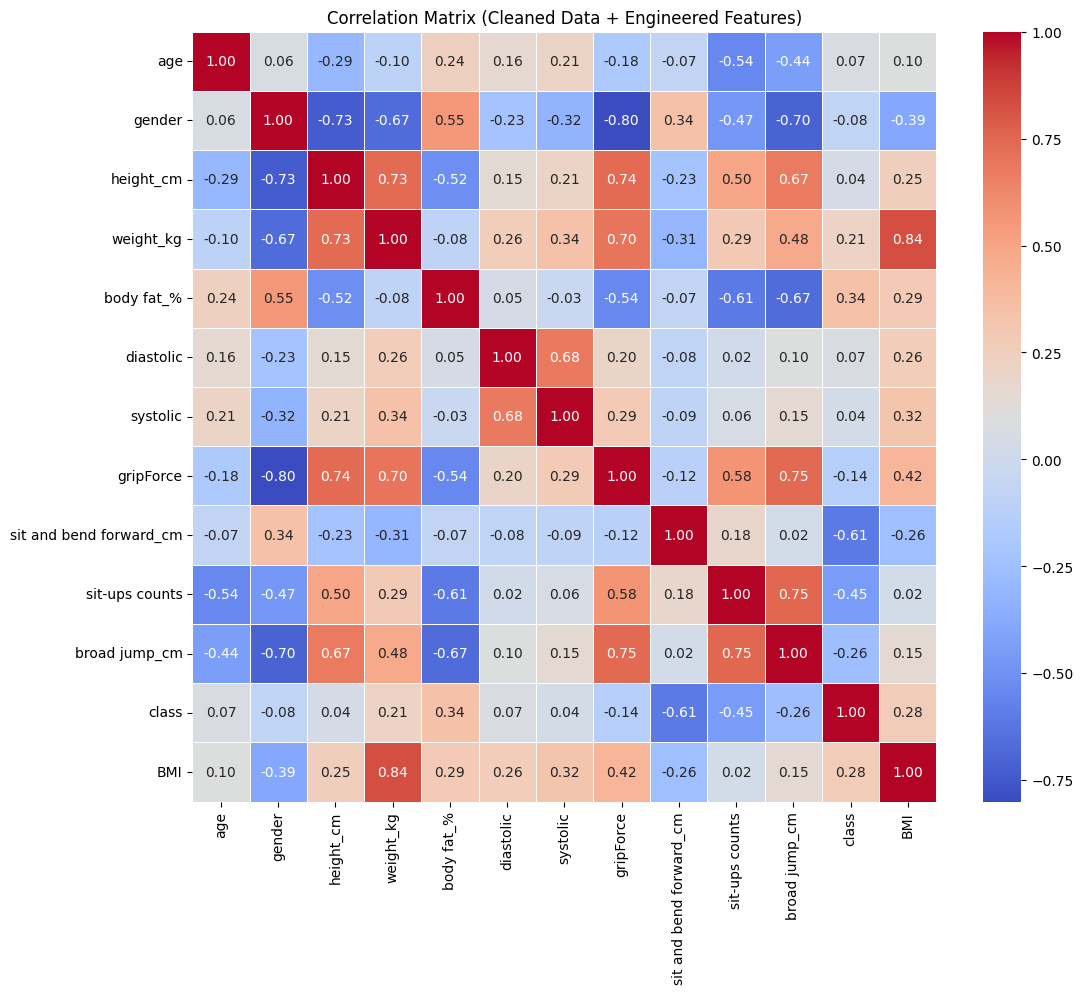

✅ Data processing complete.
📊 Remaining records: 13386
💡 Note: 'class' has been encoded as: ['A', 'B', 'C', 'D']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Load the dataset
df2 = pd.read_csv('bodyPerformance.csv')

# 2. Data Cleaning & Handling Logical Errors
# Remove impossible blood pressure values
df2 = df2[(df2['systolic'] > 40) & (df2['diastolic'] > 40)]

# Cap "sit and bend forward_cm" to handle extreme outliers/input errors
# Limits are set based on human physiological possibility
df2['sit and bend forward_cm'] = df2['sit and bend forward_cm'].clip(lower=-20, upper=50)

# 3. Feature Engineering
# Create BMI feature to provide better context for the model
df2['BMI'] = df2['weight_kg'] / ((df2['height_cm'] / 100) ** 2)

# 4. Encoding Categorical Variables
# Convert Gender to binary
df2['gender'] = df2['gender'].map({'M': 0, 'F': 1})

# Encode Target Class (A=0, B=1, C=2, D=3)
le = LabelEncoder()
df2['class'] = le.fit_transform(df2['class'])

# 5. Multivariate Analysis: Correlation Matrix
# Select numerical columns including our new BMI and encoded gender
num_cols = df2.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df2[num_cols].corr()

# Plotting the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix (Cleaned Data + Engineered Features)")
plt.show()

# 6. Final Summary
print(f"✅ Data processing complete.")
print(f"📊 Remaining records: {len(df2)}")
print(f"💡 Note: 'class' has been encoded as: {list(le.classes_)}")

In [ ]:
df2.head(20)

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class,BMI
0,27.0,0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,2,25.344179
1,25.0,0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,0,20.495868
2,31.0,0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,2,24.181428
3,32.0,0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,1,23.349562
4,28.0,0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,1,22.412439
5,36.0,1,165.4,55.40,22.0,64.0,119.0,23.8,21.0,27.0,153.0,1,20.250640
6,42.0,1,164.5,63.70,32.2,72.0,135.0,22.7,0.8,18.0,146.0,3,23.540063
7,33.0,0,174.9,77.20,36.9,84.0,137.0,45.9,12.3,42.0,234.0,1,25.236997
8,54.0,0,166.8,67.50,27.6,85.0,165.0,40.4,18.6,34.0,148.0,2,24.261167
9,28.0,0,185.0,84.60,14.4,81.0,156.0,57.9,12.1,55.0,213.0,1,24.718773


## **Linear Regression Model**

**Import Required Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

**Define Features (X) and Target (y)**

In [ ]:
y = df2['broad jump_cm']      # Target variable
X = df2.drop('broad jump_cm', axis=1)   # Input features


# Convert categorical variables to numeric
X = pd.get_dummies(X, drop_first=True)

**Train/Test Split (80:20)**

In [ ]:
# Split data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% for testing
    random_state=42    # Ensures reproducibility
)

**Create Pipeline (Scaling + Model)**

In [ ]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),     # Feature scaling
    ("model", LinearRegression())     # Linear Regression
])

**Training Linear Regression Model**

In [ ]:
# Train the model
# Fit the model using the training data
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

**Make predictions**

In [ ]:
# Predict target values for the test set
y_pred = pipeline.predict(X_test)

**Evaluation Metrics**

In [ ]:
# Evaluate model performance

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate R-squared score
r2 = r2_score(y_test, y_pred)


# Display results
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R²) Score:", r2)

Mean Squared Error (MSE): 324.9460604740038
Root Mean Squared Error (RMSE): 18.026260301959578
R-squared (R²) Score: 0.7998870529152954


**Compare actual vs predicted values**

In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison.head()

,Actual,Predicted
12186,246.0,227.913406
8992,251.0,231.216587
12131,202.0,188.555915
626,225.0,216.570321
2179,193.0,192.934069


**Visualization**

Enhanced Actual vs Predicted Plot

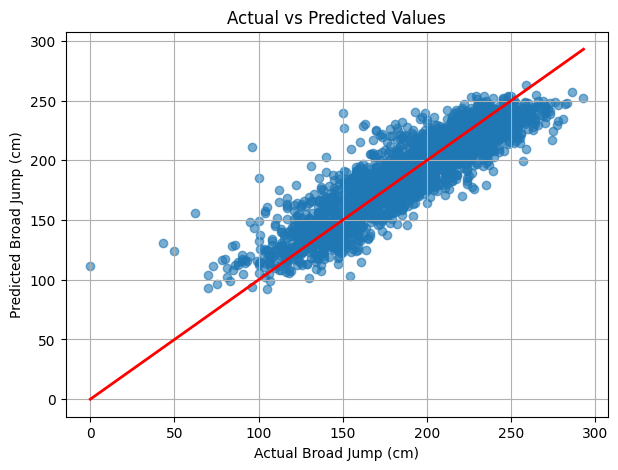

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred, alpha=0.6)

# Ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Broad Jump (cm)")
plt.ylabel("Predicted Broad Jump (cm)")
plt.title("Actual vs Predicted Values")

plt.grid(True)

plt.show()

**Residual Analysis**

Enhanced Residual Plot

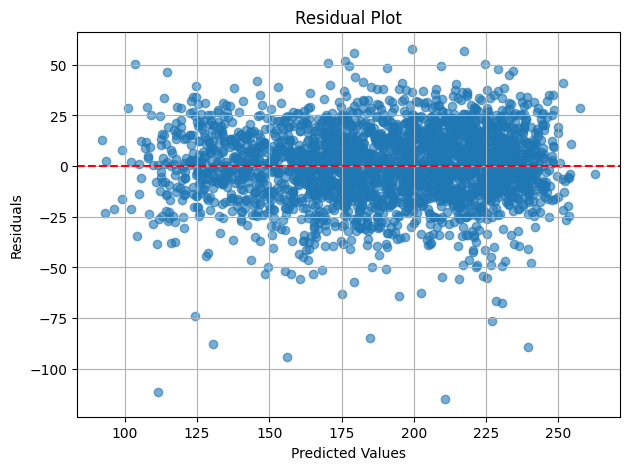

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.grid(True)

plt.show()

**Error Distribution**

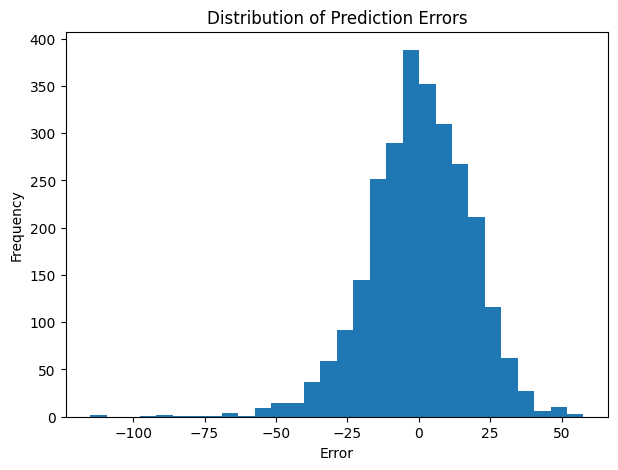

In [ ]:
plt.figure(figsize=(7,5))

plt.hist(residuals, bins=30)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()

**Feature Importance (Coefficients)**

In [ ]:
coefficients = pipeline.named_steps['model'].coef_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", key=abs, ascending=False)

feature_importance.head(10)

,Feature,Coefficient
1,gender,-13.315808
3,weight_kg,-9.222921
0,age,-8.731174
11,BMI,8.182994
2,height_cm,7.921047
4,body fat_%,-7.351020
9,sit-ups counts,7.101443
7,gripForce,6.357256
8,sit and bend forward_cm,3.139659
10,class,-3.026660


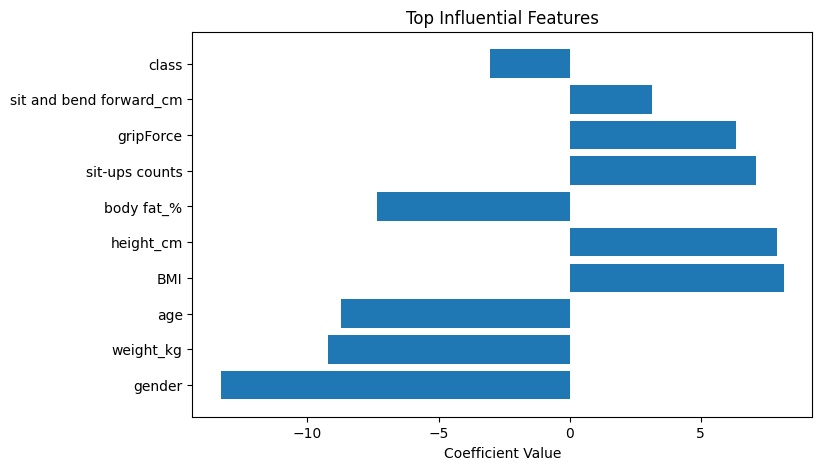

In [ ]:
plt.figure(figsize=(8,5))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Coefficient"][:10]
)

plt.title("Top Influential Features")
plt.xlabel("Coefficient Value")

plt.show()

**Experiment 70:30 Split**

In [ ]:
# Split the dataset (70% training, 30% testing)
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# Train model
model_70 = LinearRegression()
model_70.fit(X_train_70, y_train_70)

# Predict
y_pred_70 = model_70.predict(X_test_70)

# Evaluate
mse_70 = mean_squared_error(y_test_70, y_pred_70)
rmse_70 = np.sqrt(mse_70)
r2_70 = r2_score(y_test_70, y_pred_70)

print("70:30 Split Results")
print("MSE:", mse_70)
print("RMSE:", rmse_70)
print("R²:", r2_70)

70:30 Split Results
MSE: 319.87461678668626
RMSE: 17.88503890928634
R²: 0.8032765509504123


**Experiment 50:50 Split**

In [ ]:
# Split the dataset (50% training, 50% testing)
X_train_50, X_test_50, y_train_50, y_test_50 = train_test_split(
    X, y,
    test_size=0.5,
    random_state=42
)

# Train model
model_50 = LinearRegression()
model_50.fit(X_train_50, y_train_50)

# Predict
y_pred_50 = model_50.predict(X_test_50)

# Evaluate
mse_50 = mean_squared_error(y_test_50, y_pred_50)
rmse_50 = np.sqrt(mse_50)
r2_50 = r2_score(y_test_50, y_pred_50)

print("50:50 Split Results")
print("MSE:", mse_50)
print("RMSE:", rmse_50)
print("R²:", r2_50)

50:50 Split Results
MSE: 319.9043031361534
RMSE: 17.88586881133129
R²: 0.7991747641442145


**K-Fold Cross Validation**

In [ ]:
# Perform 5-Fold Cross Validation
cv_scores = cross_val_score(
    pipeline,
    X, y,
    cv=5,
    scoring='r2'   # Using R² as evaluation metric
)

print("Cross Validation R² Scores:", cv_scores)
print("Average R² Score:", cv_scores.mean())

Cross Validation R² Scores: [0.78113776 0.78014888 0.78327457 0.8023086  0.78923517]
Average R² Score: 0.7872209953918498


**Compare all experiments**

In [ ]:
results = pd.DataFrame({
    "Experiment": ["80:20", "70:30", "50:50"],
    "R2 Score": [r2, r2_70, r2_50],
    "RMSE": [rmse, rmse_70, rmse_50]
})

results

,Experiment,R2 Score,RMSE
0,80:20,0.799887,18.026260
1,70:30,0.803277,17.885039
2,50:50,0.799175,17.885869


**Visualization of R² scores**

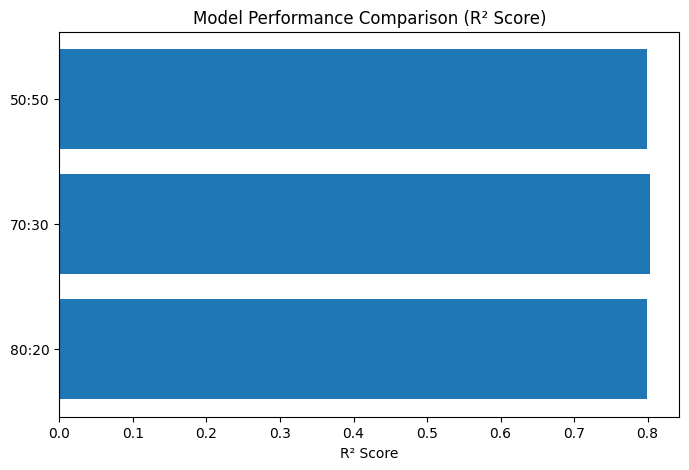

In [ ]:
plt.figure(figsize=(8,5))

plt.barh(results["Experiment"], results["R2 Score"])

plt.title("Model Performance Comparison (R² Score)")

plt.xlabel("R² Score")

plt.show()

**Professional Prediction Function**

Predict Broad Jump Distance for New Person

In [ ]:
import pandas as pd

def predict_jump(age, gender, height_cm, weight_kg,
                 body_fat_percent, diastolic_bp, systolic_bp,
                 grip_force, flexibility_cm, sit_ups,
                 performance_class):

  # Step 1: Create DataFrame for new sample
  new_person = pd.DataFrame({
        'age': [age],
        'gender': [gender],
        'height_cm': [height_cm],
        'weight_kg': [weight_kg],
        'body_fat_percent': [body_fat_percent],
        'diastolic_bp': [diastolic_bp],
        'systolic_bp': [systolic_bp],
        'grip_force': [grip_force],
        'flexibility_cm': [flexibility_cm],
        'sit_ups': [sit_ups],
        'performance_class': [performance_class]
    })

  # Step 2: Apply One-Hot Encoding
  new_person_encoded = pd.get_dummies(new_person, drop_first=True)

  # Step 3: Align columns with training data
  new_person_encoded = new_person_encoded.reindex(
        columns=X.columns,
        fill_value=0
    )

  # Step 4: Predict using trained model
  prediction = pipeline.predict(new_person_encoded)

  # Step 5: Return prediction result
  return prediction[0]

In [ ]:
result = predict_jump(
    age=25,
    gender='Male',
    height_cm=175,
    weight_kg=70,
    body_fat_percent=15,
    diastolic_bp=80,
    systolic_bp=120,
    grip_force=40,
    flexibility_cm=18,
    sit_ups=45,
    performance_class='B'
)

print("Predicted Broad Jump (cm):", result)

Predicted Broad Jump (cm): 120.83622069197204


**Performance Recommendation System**

In [ ]:
def recommend_performance(age, gender, height_cm, weight_kg,
                          body_fat_percent, diastolic_bp, systolic_bp,
                          grip_force, flexibility_cm, sit_ups,
                          performance_class):

    # Predict jump using the previous function
    predicted_jump = predict_jump(
        age, gender, height_cm, weight_kg,
        body_fat_percent, diastolic_bp, systolic_bp,
        grip_force, flexibility_cm, sit_ups,
        performance_class
    )

    # Generate recommendation
    if predicted_jump >= 250:
        level = "Excellent"
        advice = "Maintain your training program."

    elif predicted_jump >= 200:
        level = "Good"
        advice = "Improve strength and explosive exercises."

    elif predicted_jump >= 150:
        level = "Average"
        advice = "Focus on leg strength and flexibility."

    else:
        level = "Below Average"
        advice = "Increase physical activity and endurance training."


    print("Predicted Broad Jump:", round(predicted_jump, 2), "cm")
    print("Performance Level:", level)
    print("Recommendation:", advice)

In [ ]:
recommend_performance(
    25, 'Male', 175, 70, 15, 80, 120, 40, 18, 45, 'B'
)

Predicted Broad Jump: 120.84 cm
Performance Level: Below Average
Recommendation: Increase physical activity and endurance training.


**Define different train-test splits**

In [ ]:
splits = {
    "80:20": 0.2,
    "70:30": 0.3,
    "50:50": 0.5
}

**Run experiments automatically**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

results = []

for name, test_size in splits.items():

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42
    )

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Save results
    results.append([name, r2, rmse, mse])

# Convert to DataFrame
results_df = pd.DataFrame(
    results,
    columns=["Split", "R2 Score", "RMSE", "MSE"]
)

results_df

,Split,R2 Score,RMSE,MSE
0,80:20,0.799887,18.026260,324.946060
1,70:30,0.803277,17.885039,319.874617
2,50:50,0.799175,17.885869,319.904303


**Sort by best R² score**

In [ ]:
results_df = results_df.sort_values(by="R2 Score", ascending=False)

results_df

,Split,R2 Score,RMSE,MSE
1,70:30,0.803277,17.885039,319.874617
0,80:20,0.799887,18.026260,324.946060
2,50:50,0.799175,17.885869,319.904303


**Visualization**

**R² Comparison**

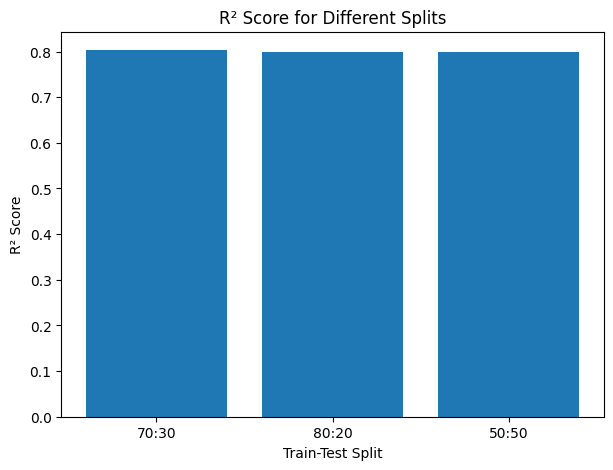

In [ ]:
plt.figure(figsize=(7,5))

plt.bar(results_df["Split"], results_df["R2 Score"])

plt.title("R² Score for Different Splits")

plt.xlabel("Train-Test Split")
plt.ylabel("R² Score")

plt.show()

**RMSE Comparison**

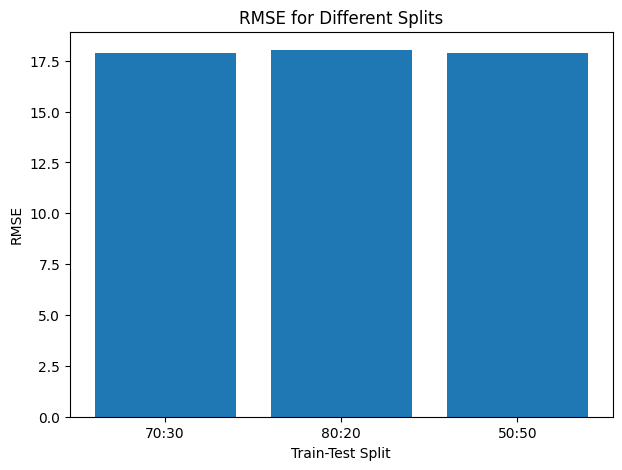

In [ ]:
plt.figure(figsize=(7,5))

plt.bar(results_df["Split"], results_df["RMSE"])

plt.title("RMSE for Different Splits")

plt.xlabel("Train-Test Split")
plt.ylabel("RMSE")

plt.show()

**All Metrics Together**

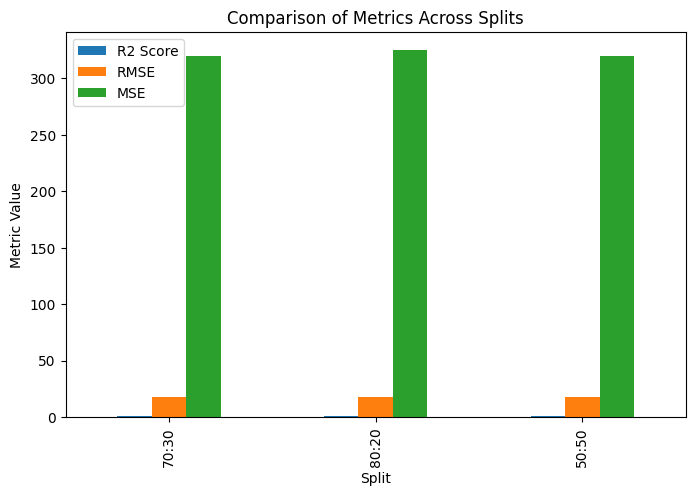

In [ ]:
results_df.set_index("Split").plot(kind="bar", figsize=(8,5))

plt.title("Comparison of Metrics Across Splits")

plt.ylabel("Metric Value")

plt.show()

**Determine best split scientifically**

In [ ]:
best_r2 = results_df.loc[results_df["R2 Score"].idxmax()]
best_rmse = results_df.loc[results_df["RMSE"].idxmin()]

print("Best Split by R²:")
print(best_r2)

print("\nBest Split by RMSE:")
print(best_rmse)

Best Split by R²:
Split            70:30
R2 Score      0.803277
RMSE         17.885039
MSE         319.874617
Name: 1, dtype: object

Best Split by RMSE:
Split            70:30
R2 Score      0.803277
RMSE         17.885039
MSE         319.874617
Name: 1, dtype: object


**K-Fold Cross Validation**

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
import numpy as np

model = LinearRegression()


# K-Fold configuration
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Run Cross Validation
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=kfold,
    scoring='r2'
)

cv_scores

array([0.79988705, 0.81002533, 0.7802217 , 0.763429  , 0.78308857])

**Average Score**

In [ ]:
print("R² Scores for each fold:", cv_scores)
print("Average R²:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

R² Scores for each fold: [0.79988705 0.81002533 0.7802217  0.763429   0.78308857]
Average R²: 0.7873303284947686
Standard Deviation: 0.016202056156715067


**Visualization**

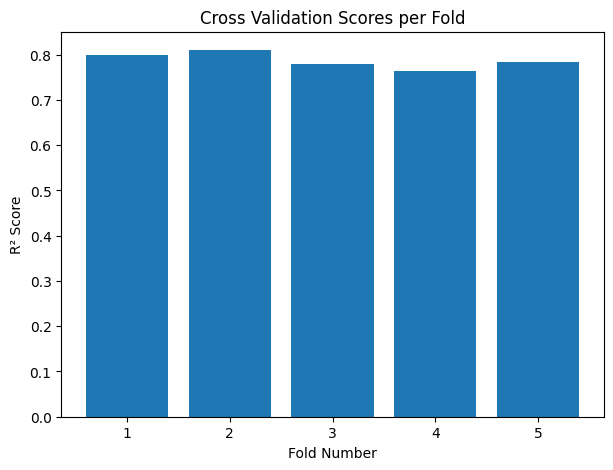

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(range(1, 6), cv_scores)

plt.xlabel("Fold Number")
plt.ylabel("R² Score")

plt.title("Cross Validation Scores per Fold")

plt.show()

**Error Bars Visualization**

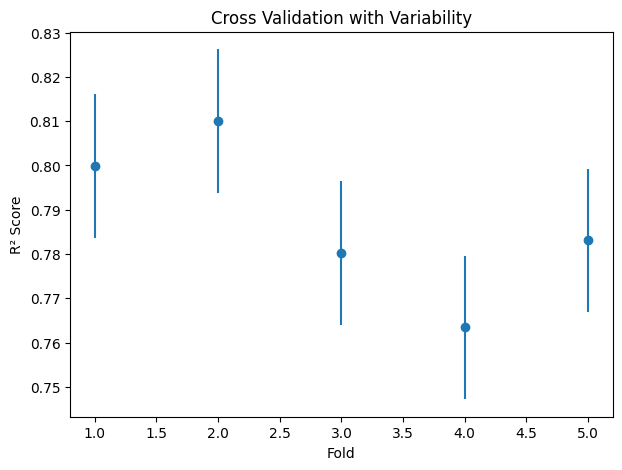

In [ ]:
plt.figure(figsize=(7,5))

plt.errorbar(
    range(1, 6),
    cv_scores,
    yerr=cv_scores.std(),
    fmt='o'
)

plt.xlabel("Fold")
plt.ylabel("R² Score")

plt.title("Cross Validation with Variability")

plt.show()

**Cross Validation + RMSE**

In [ ]:
rmse_scores = np.sqrt(
    -cross_val_score(
        model,
        X,
        y,
        cv=kfold,
        scoring='neg_mean_squared_error'
    )
)

print("RMSE per fold:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())

RMSE per fold: [18.0262603  17.4026718  18.53952952 19.3570937  18.50834868]
Average RMSE: 18.366780799608772
